# Project Group7 : Yihang Wang, Aaron Sukare

## Research Question1: Who adopts Coding Agents on GitHub?

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#load data
all_pr_df = pd.read_parquet("hf://datasets/hao-li/AIDev/all_pull_request.parquet")
all_user_df = pd.read_parquet("hf://datasets/hao-li/AIDev/all_user.parquet")
print("all_pull_request shape:",all_pr_df.shape)
print("all_user shape:",all_user_df.shape)
print("user columns sample:",list(all_user_df.columns)[:10])
print("agent counts sample:")
print(all_pr_df["agent"].value_counts().head(10))
#keep only PRs where agent is present
all_pr_df = all_pr_df[all_pr_df["agent"].notna()]
print("all_pull_request with_agent shape:",all_pr_df.shape)

all_pull_request shape: (932791, 14)
all_user shape: (72189, 5)
user columns sample: ['id', 'login', 'followers', 'following', 'created_at']
agent counts sample:
agent
OpenAI_Codex    814522
Copilot          50447
Cursor           32941
Devin            29744
Claude_Code       5137
Name: count, dtype: int64
all_pull_request with_agent shape: (932791, 14)


In [30]:
#pick user columns that actually exist
want_user_cols = ["id","login","created_at","followers","public_repos"]
have_user_cols = [c for c in want_user_cols if c in all_user_df.columns]
user_info = all_user_df[have_user_cols].drop_duplicates(subset="id")
pr_info = all_pr_df[["id","user_id","created_at","agent","repo_id"]].copy()
user_info["created_at"] = pd.to_datetime(user_info["created_at"],errors="coerce")
pr_info["created_at"] = pd.to_datetime(pr_info["created_at"],errors="coerce")
print("user_info shape:",user_info.shape)
print("pr_info shape:",pr_info.shape)

user_info shape: (72168, 4)
pr_info shape: (932791, 5)


In [31]:
#compute basic stats per developer from PR table
pr_group = pr_info.groupby("user_id")
user_stats = pr_group.agg(first_agent_pr=("created_at","min"),last_agent_pr=("created_at","max"),num_agent_pr=("id","count"),num_agent_repos=("repo_id","nunique")).reset_index()
user_stats = user_stats.rename(columns={"user_id":"id"})
dev_df = user_info.merge(user_stats,on="id",how="inner")
print("dev_df shape:",dev_df.shape)
dev_df.head()

dev_df shape: (72167, 8)


,id,login,created_at,followers,first_agent_pr,last_agent_pr,num_agent_pr,num_agent_repos
0,149159513.0,00012122Cs,2023-10-27 10:22:50+00:00,0.0,2025-06-06 21:22:49+00:00,2025-06-06 21:43:40+00:00,3,1
1,86906973.0,000Sean000,2021-07-04 07:05:40+00:00,0.0,2025-06-04 07:07:52+00:00,2025-06-04 07:07:52+00:00,1,1
2,36679210.0,000alen,2018-02-20 21:00:55+00:00,46.0,2025-05-25 17:09:59+00:00,2025-05-26 01:02:18+00:00,2,1
3,201261210.0,000qhrey,2025-02-28 16:53:21+00:00,0.0,2025-05-17 05:00:59+00:00,2025-05-17 07:59:56+00:00,2,2
4,22735204.0,00125495,2016-10-10 01:24:34+00:00,0.0,2025-07-05 06:36:14+00:00,2025-07-05 06:36:14+00:00,1,1


In [32]:
#tenure and simple experience label
dev_df["tenure_days_at_first_pr"] = (dev_df["first_agent_pr"] - dev_df["created_at"]).dt.days
dev_df["tenure_years_at_first_pr"] = dev_df["tenure_days_at_first_pr"] / 365.25
def label_experience(years):
    if pd.isna(years):
        return "unknown"
    if years < 1:
        return "newcomer"
    if years < 3:
        return "intermediate"
    return "experienced"
dev_df["experience_level"] = dev_df["tenure_years_at_first_pr"].apply(label_experience)
neg_mask = dev_df["tenure_days_at_first_pr"] < 0
dev_df.loc[neg_mask,"experience_level"] = "unknown"
dev_df[["tenure_years_at_first_pr","experience_level"]].head()

,tenure_years_at_first_pr,experience_level
0,1.609856,intermediate
1,3.917864,experienced
2,7.255305,experienced
3,0.210815,newcomer
4,8.733744,experienced


In [33]:
#counts by experience level
exp_counts = dev_df.groupby("experience_level")["id"].nunique().reset_index(name="num_developers").sort_values("num_developers",ascending=False)
print("number_of_devs_by_experience_level")
print(exp_counts)

number_of_devs_by_experience_level
  experience_level  num_developers
0      experienced           45173
2         newcomer           13985
1     intermediate           13009


In [34]:
#median stats per level
agg_dict = {"median_tenure_years":("tenure_years_at_first_pr","median"),"median_num_agent_pr":("num_agent_pr","median"),"median_num_agent_repos":("num_agent_repos","median")}
if "followers" in dev_df.columns:
    agg_dict["median_followers"] = ("followers","median")
if "public_repos" in dev_df.columns:
    agg_dict["median_public_repos"] = ("public_repos","median")
exp_summary = dev_df.groupby("experience_level").agg(**agg_dict).reset_index()
print("experience_level_summary")
print(exp_summary)

experience_level_summary
  experience_level  median_tenure_years  median_num_agent_pr  \
0      experienced             7.531828                  2.0   
1     intermediate             2.036961                  2.0   
2         newcomer             0.186174                  2.0   

   median_num_agent_repos  median_followers  
0                     1.0               2.0  
1                     1.0               0.0  
2                     1.0               0.0  


In [35]:
#adoption rate among all users in all_user_df (within this dataset)
all_user_ids = set(user_info["id"])
adopter_ids = set(dev_df["id"])
if len(all_user_ids) > 0:
    adoption_rate = len(adopter_ids) / len(all_user_ids)
else:
    adoption_rate = np.nan
print("adoption_rate_all_users:",adoption_rate)

adoption_rate_all_users: 0.9999861434430772


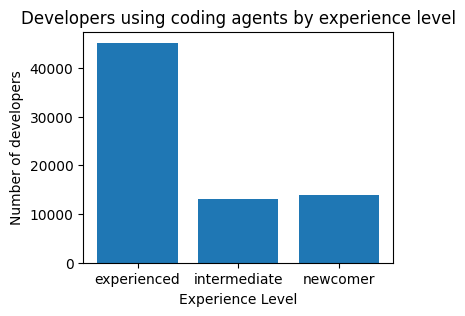

In [36]:
#bar plot for number of adopters by experience level
exp_counts_plot = exp_counts.sort_values("experience_level")
plt.figure(figsize=(4,3))
plt.bar(exp_counts_plot["experience_level"],exp_counts_plot["num_developers"])
plt.xlabel("Experience Level")
plt.ylabel("Number of developers")
plt.title("Developers using coding agents by experience level")
plt.show()

In this dataset, coding agents are mostly adopted by experienced developers.